# Tidal stripping: the reshape-after-each-step over-stripping artefact

A side-by-side comparison with the tidal-stripping pattern in `SatEvo.py` and `test_evolve.py`, which use a fresh `Dekel` profile re-fitted from the Penarrubia+10 tidal-track parameters at every step. The reshape silently regenerates the outer Dekel tail after each pass — material the tidal stripping just removed is partly reintroduced on the next iteration — so the effective stripping rate is amplified beyond what the underlying physics supports. Errani+Navarro21 found that density profile shapes after stripping are exponentially cut at their tidal radius.

The Du+24 shell-expansion path does tidal heating without the reshape: `heat_profile` evolves a `NumericProfile` so tidal stripping unbinds outer shells and the profile is truncated.

Three prescriptions on the same setup ($10^9\,M_\odot$ NFW host, Segue I-like, with a $10^6\,M_\odot$ Dekel subhalo on an eccentric orbit):

- **SatGen P10/Dekel (the naive reshape pattern):** `evolve.msub` + `Dekel(c, alpha)` re-fitted at every step. This is what `SatEvo.py` / `test_evolve.py` do.
- **Du+24 shell heating, first-order:** `heat_profile` under per-step $\varepsilon(r) \propto r^2$ injection (Pullen+14), with King62 stripping layered on top.
- **Du+24 + Benson+Du22 second-order:** adds the $\varepsilon_2 \propto \sqrt{\varepsilon_1\,\sigma_r^2}$ correction (Benson+Du22 eq. 4), accumulated along the orbit and applied per timestep so the per-step increments add up to the per-orbit shock.

The primary Benson+Du22 reproduction (SIS host, NFW subhalo, Errani+Navarro 21 fit) lives in `stripping_sis.ipynb`. The Milky-Way-scale cross-check against SatGen's DASH/Green builtin is in `stripping_nfw.ipynb`.

In [1]:
import config as cfg
import cosmo as co
from profiles import NFW, Dekel, Einasto, MN, Vcirc, ftot, fDF, tdyn
from orbit import orbit
import evolve as ev
import galhalo as gh

import aux
from subhalo_functions import heat_profile, NumericProfile, tidalTensor
import stripping_common as sc

import numpy as np
from scipy.optimize import bisect
import time
import sys

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib inline

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


## Initialize Subhalo and Host Profile

We initialize the mass resolution, the host profile and the subhalo (including its initial phase space). The subhalo has a Dekel profile (which is the standard in SatGen)

In [2]:
cfg.Mres = 1e1

#---host and satellite parameters
Mv     = 1e9    # host virial mass [Msun]
cNFW   = 11.68  # host NFW concentration
mv0    = 1e6    # satellite virial mass at infall [Msun]
cDekel0 = 100.  # satellite Dekel concentration
aDekel0 = 1.0 + cfg.eps

#---tidal heating parameters
epsh  = 3.
gamma = 2.5

#---time integration
Nstep = 10000
tmax  = 10.  # [Gyr]

#---build host and satellite
hNFW      = NFW(Mv, cNFW)
potential = hNFW
sat_dekel = Dekel(mv0, cDekel0, aDekel0)

#---initial orbital position (circular orbit at R0=1 kpc)
R0, z0 = 0.7*hNFW.rh, 0.
xv0, _    = sc.make_orbit(hNFW, R0=R0, z0=z0, eta=0.5)

print(f"Host  : rh = {hNFW.rh:.2f} kpc, rs = {hNFW.rs:.2f} kpc")
print(f"Sat   : rh = {sat_dekel.rh:.2f} kpc, rs = {sat_dekel.rs:.2f} kpc")
print(f"xv0   : R={xv0[0]:.4f} kpc, Vphi={xv0[4]:.4f} kpc/Gyr")

Host  : rh = 20.63 kpc, rs = 1.77 kpc
Sat   : rh = 2.06 kpc, rs = 0.02 kpc
xv0   : R=14.4402 kpc, Vphi=7.9857 kpc/Gyr


In [3]:
import time
t1 = time.time()
result_A = sc.evolve_satgen_dekel(hNFW, sat_dekel, xv0, tmax=tmax, Nstep=Nstep)
t2 = time.time()
print(f'SatGen P10/Dekel: {t2-t1:.2f} s')

SatGen P10/Dekel: 4.76 s


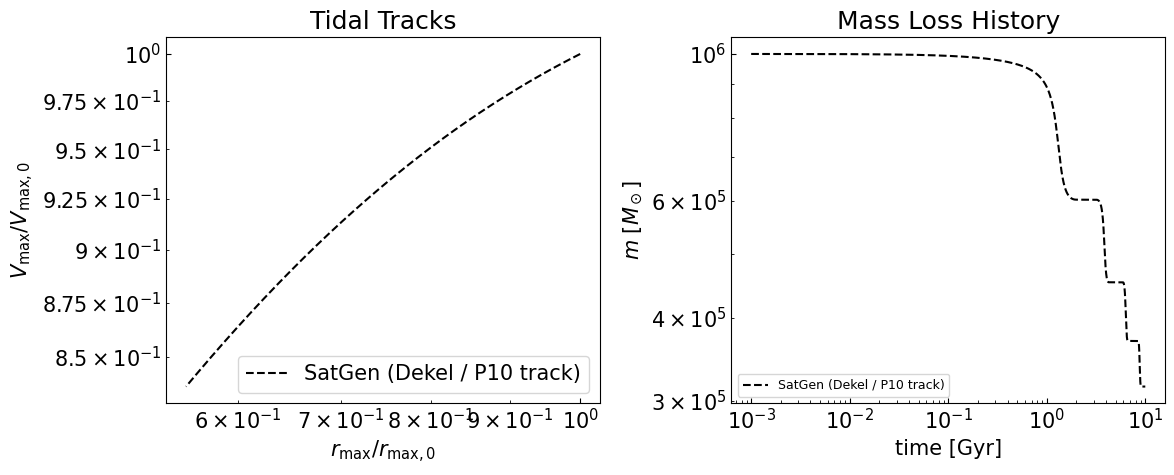

In [4]:
#---SatGen P10/Dekel: dashed black line, the convention used in this notebook
#   for the baseline reference (matches the comparison and orbital-radius cells).
style = [dict(color='black', linestyle='--', linewidth=1.5)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track(result_A, ax=axes[0], styles=style)
sc.plot_mass_loss(result_A, ax=axes[1], styles=style)
plt.tight_layout()
plt.show()

## Du+24 shell-based heating

`heat_profile` evolves a `NumericProfile` under the Du+24 monotonic shell expansion with per-step $\varepsilon(r) \propto r^2$ injection (Pullen+14).

In [5]:
rvals = np.logspace(np.log10(cfg.Rres), np.log10(sat_dekel.rh), 100)
numProfile0 = NumericProfile(rvals, sat_dekel.M(rvals))

t1 = time.time()
result_heat = sc.evolve_heating(hNFW, numProfile0, xv0, tmax=tmax, Nstep=Nstep,
                                epsh=epsh, gamma=gamma)
t2 = time.time()
print(f'Custom heating (Du+24): {t2-t1:.2f} s')

Custom heating (Du+24): 16.11 s


## Second-order tidal heating (Benson+Du22)

`second_order=True` adds the [Benson+Du22](https://academic.oup.com/mnras/article/517/1/1398/6726643) correction to the per-shell energy injection (their eq. 4):

$$\Delta\varepsilon_2(r) = \sqrt{2}\, f_2 (1+\chi_v) \sqrt{\Delta\varepsilon_1(r)\,\sigma_r^2(r)}$$

with $f_2 = 0.406$, $\chi_v = -0.333$, and $\sigma_r$ from the isotropic Jeans equation (`NumericProfile.sigma`). The per-step / per-orbit derivation is in `stripping_sis.ipynb`.

In [6]:
t1 = time.time()
result_heat2 = sc.evolve_heating(
    hNFW, NumericProfile(rvals, sat_dekel.M(rvals)), xv0,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma,
    second_order=True,
)
t2 = time.time()
print(f'Custom heating (Du+24) + Benson+Du22 2nd-order: {t2-t1:.2f} s')

Custom heating (Du+24) + Benson+Du22 2nd-order: 31.24 s


## Comparison: tidal tracks and mass loss

SatGen P10/Dekel against 1st- and 2nd-order shell heating on the same axes.

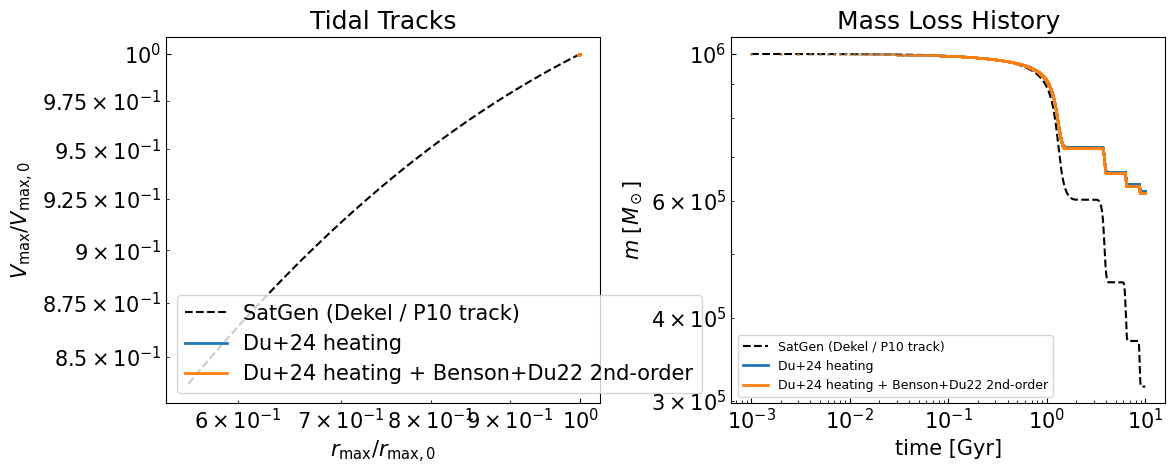

In [7]:
#---SatGen P10/Dekel: dashed black line (baseline). Shell heating: default dot
#   markers with reduced opacity so overlapping 1st/2nd-order points stay
#   visible (the dashed baseline already differentiates the over-stripping
#   cloud, so distinct markers for the heating curves aren't needed).
styles = [
    dict(color='black', linestyle='--', linewidth=1.5),
    dict(marker='.', linestyle='None', ms=2, alpha=0.5),
    dict(marker='.', linestyle='None', ms=2, alpha=0.5),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track([result_A, result_heat, result_heat2], ax=axes[0], styles=styles)
sc.plot_mass_loss([result_A, result_heat, result_heat2], ax=axes[1], styles=styles)
plt.tight_layout()
plt.show()

## Profile evolution snapshots

Density, enclosed mass, and circular velocity at evenly-spaced time snapshots. Colour runs from dark (early) to light (late).

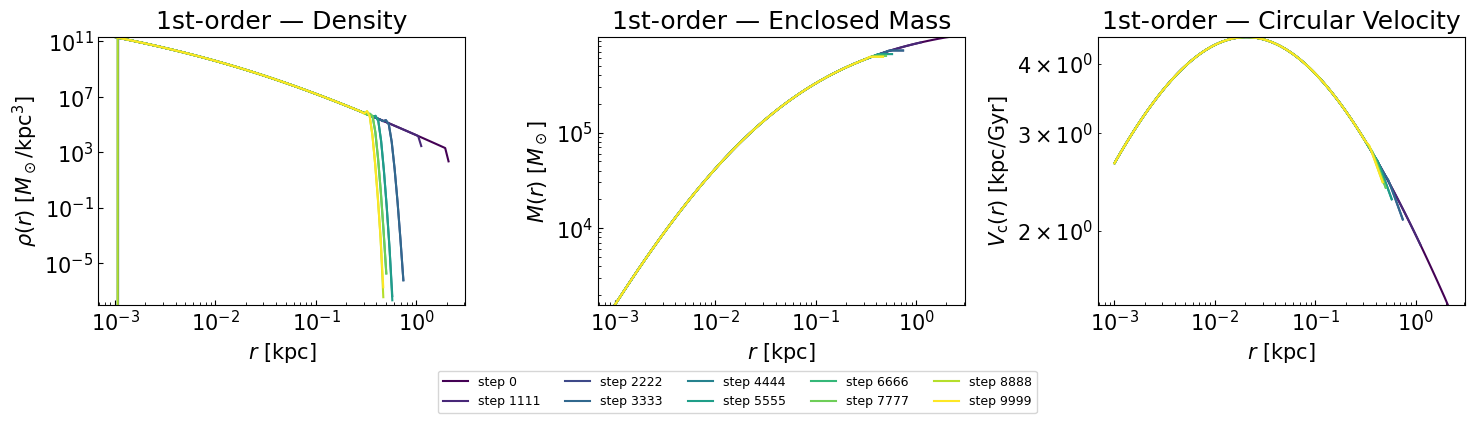

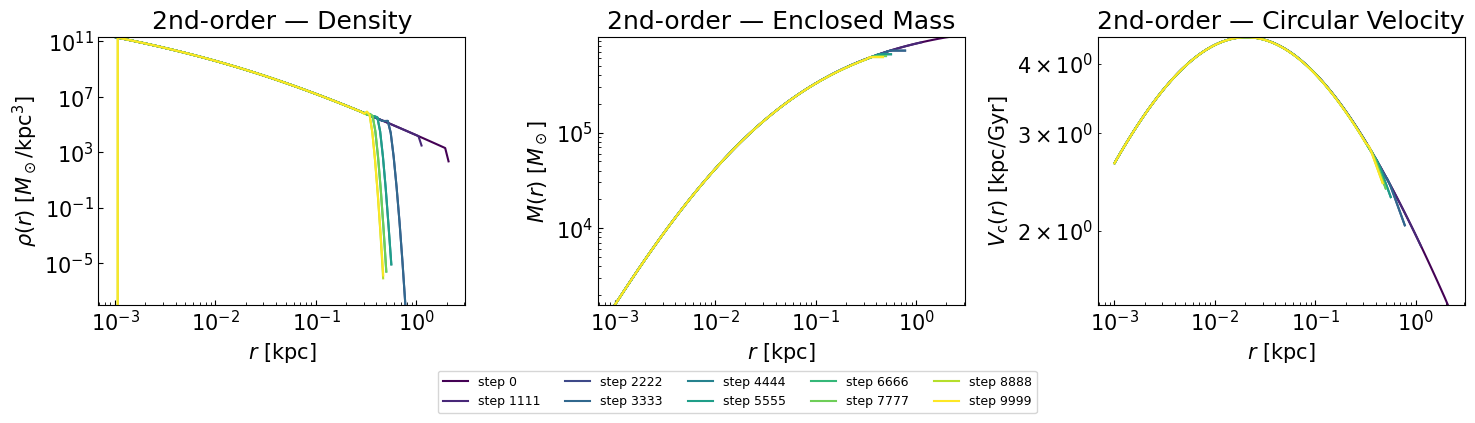

In [8]:
shared_ylims = sc.profile_ylims(result_heat, result_heat2)
for res, prefix in [(result_heat, '1st-order — '), (result_heat2, '2nd-order — ')]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sc.plot_profile_snapshots(res, axes=axes, title_prefix=prefix, ylims=shared_ylims)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=9, loc='lower center',
               bbox_to_anchor=(0.5, -0.08), ncol=5)
    plt.tight_layout()
    plt.show()

## Orbital radius

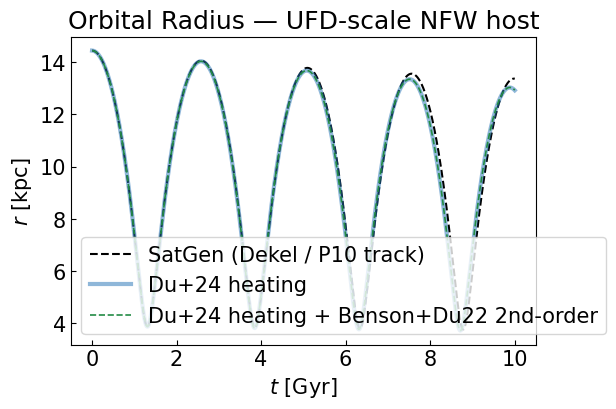

In [9]:
#---SatGen P10/Dekel baseline in dashed black; shell heating uses the SIS
#   convention (thick semi-transparent for 1st-order + thin dashed on top
#   for 2nd-order) so curves that overlap stay distinguishable
styles = [
    dict(color='black', linestyle='--', linewidth=1.5),    # SatGen P10/Dekel
    dict(color='#2171b5', linewidth=3.0, alpha=0.5),       # 1st-order
    dict(color='#238b45', linewidth=1.2, linestyle='--'),  # 2nd-order
]
sc.plot_orbit([result_A, result_heat, result_heat2], styles=styles)
plt.title('Orbital Radius — UFD-scale NFW host')
plt.show()